# What is Generalization?

**Generalization = The ability of a model to perform well on NEW, unseen data.**

Example:

Suppose you trained a house price model.

Training Data:

| Area | Price |
| ---- | ----- |
| 1000 | 100k  |
| 1200 | 120k  |
| 1500 | 150k  |

Now a new house appears:

| Area | Price |
| ---- | ----- |
| 1300 | ?     |

If your model predicts this well, it has **good generalization**.

---

## Why do we care?

Because in real life:

* We don't care about training data.
* We care about **future data**.

A model that memorizes training data but fails on new data is useless.

This is called **overfitting**.

---

# How do we improve generalization?

Many techniques exist:

* More training data
* Feature selection
* Cross Validation
* Early Stopping
* **Regularization** ✅

---

# What is Regularization?

Regularization tells the model:

> **"Don't make your coefficients unnecessarily large."**

Instead of only minimizing prediction error, we also **penalize model complexity**.

---

# Normal Cost Function
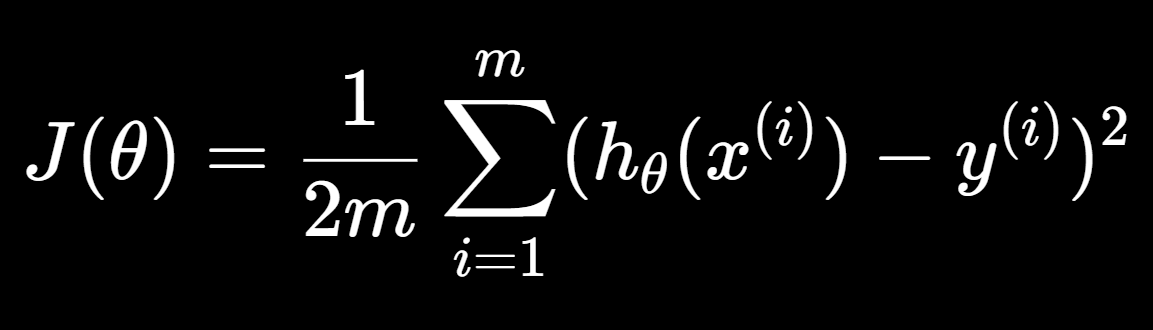
Linear Regression normally minimizes:

Cost (Prediction Error)


The only objective is:

> "Predict as accurately as possible."

Sometimes the model becomes too complex to achieve this.

---

# Regularized Cost Function
Lasso Regression equation:  
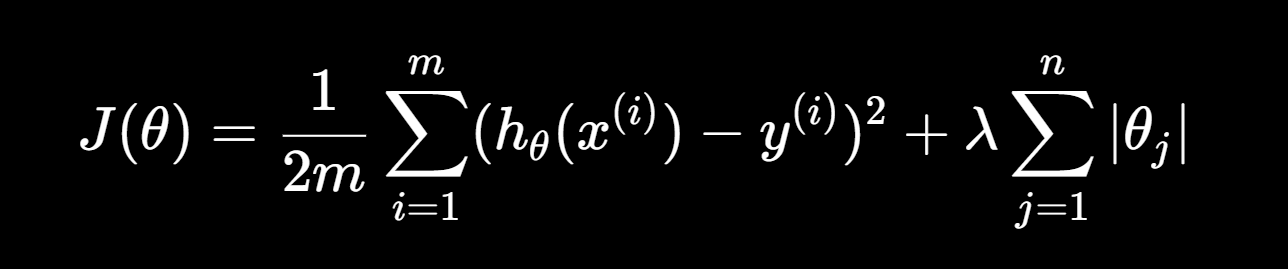
Now we change the objective.

Instead of:

```text
Cost = Error
```

we say:

```text
Cost = Error + Penalty
```

Now the model thinks:

> "I want low prediction error, **but I also want to stay simple.**"

That's the entire idea of regularization.

---

# Why add a penalty?

Imagine two students.

Student A

* Solves the question in 5 simple steps.

Student B

* Solves the same question in 200 unnecessary steps.

Both get the correct answer.

Which solution is better?

Usually Student A.

Regularization prefers the simpler solution.

---

# Lasso Regression (L1)

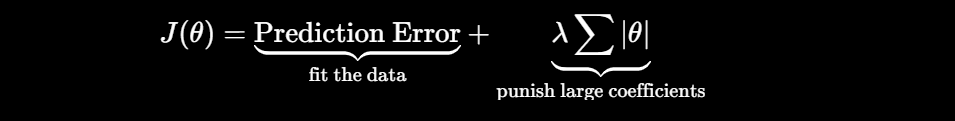
Lasso adds this penalty to the cost function equation, called lasso penalty:  

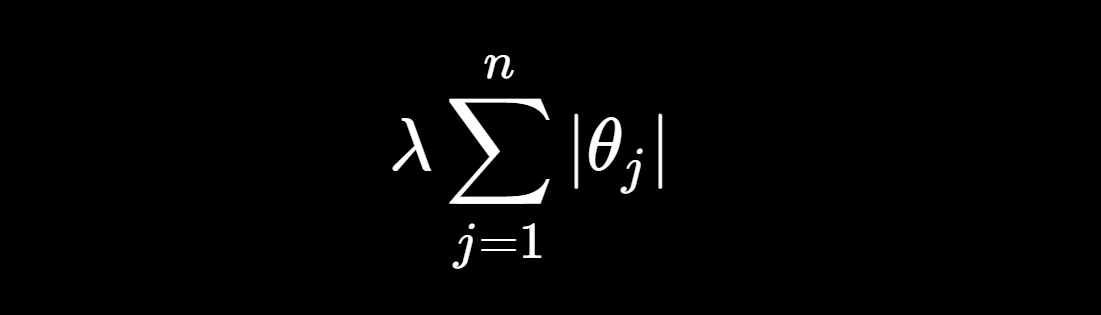

Let's understand every part.
### n

n = Number of features.  

---

### θ (theta)

These are the **coefficients (weights)**.  

θ1, θ2, θ3 etc

These are the values Lasso penalizes.  

Large coefficients → Large penalty.  
 
Small coefficients → Small penalty.  

Lasso uses Absolute Value  : ∣θ∣ 

 

---

### λ (Lambda)

Lambda controls **how strict the penalty is**.

Large λ → Large penalty → More coefficient shrinkage → Simpler model.  
Small λ → Small penalty → Less coefficient shrinkage → More complex model.  

---

# What does Lasso actually do?

Suppose your model has:

```text
Area
Bedrooms
Bathrooms
Garage
Distance
Owner Phone Number
House ID
```

Clearly:

* Area ✅ useful
* Garage ✅ useful
* House ID ❌ useless
* Phone Number ❌ useless

Without Lasso, the model might still assign tiny non-zero weights to those useless features.

Example:

```text
Area = 220
Garage = 9000
House ID = 2.3
Phone Number = 0.7
```

Lasso pushes unimportant coefficients to exactly **0**.

After training:

```text
Area = 220
Garage = 9000
House ID = 0
Phone Number = 0
```

The useless features disappear from the model.

---

# Why is that useful?

The model becomes:

* Simpler
* Easier to understand
* Less likely to overfit
* Better at generalizing

This is why Lasso is often said to perform **automatic feature selection**.

---

# Why not just use normal Linear Regression?

Suppose you have:

* 500 features
* Only 100 are actually useful

Normal Linear Regression may try to fit noise from the remaining 400 features.

Result:

Training R² = 0.99 ✅

Test R² = 0.74 ❌

It overfits.

Lasso removes many of those unnecessary features.

Result:

Training R² = 0.95

Test R² = 0.89 ✅

Training performance decreases slightly, but performance on unseen data improves.

---

# When do we use Lasso?

Use it when:

* You have many features.
* Some features are irrelevant.
* You suspect overfitting.
* You want automatic feature selection.
* You want a simpler, more interpretable model.

Examples:

* Predicting house prices with hundreds of property attributes.
* Medical datasets with thousands of measurements.
* Text classification with thousands of words as features.

---

# What if we don't use it?

If your model is already simple and doesn't overfit, you may not need Lasso.

But if you ignore regularization when it's needed, you may get:

* Overfitting
* Poor generalization
* Unstable coefficients
* Complex models that are hard to interpret

---

# Intuition to remember

Imagine you're packing for a trip.

Without Lasso:

> "Take everything. It might be useful."

You end up carrying 50 kg of luggage.

With Lasso:

> "If an item isn't helping enough, leave it behind."

You carry only the essentials.

The destination (prediction) is the same, but your journey (model) is much simpler.

---

## Lasso in one sentence

> **Lasso Regression is Linear Regression with a penalty that forces unimportant feature coefficients to become exactly zero, automatically removing them, reducing overfitting, and improving generalization on unseen data.**



---

# Ridge Regression (L2 Regularization)

Cost function:

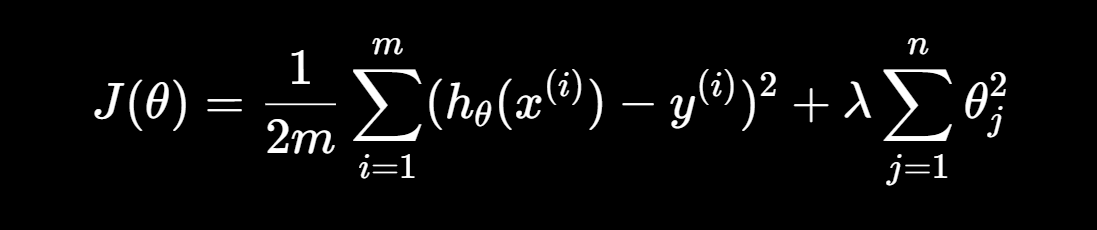

Just like Lasso:

> **Total Cost = Prediction Error + Penalty**

The **prediction error part is identical**.

The only difference is the penalty.

---

## Lasso vs Ridge Penalty

### Lasso (L1)



Penalty = **sum of absolute values**


### Ridge (L2)


Penalty = **sum of squares**

---

# Why square them?

Squaring makes **large coefficients much more expensive** than small ones.

> **"If a coefficient becomes very large, ridge punishes it very heavily."**

---

# What does Ridge do?

Suppose your model learns:

```text
Area = 220
Bedrooms = 15
Garage = 9000
Distance = -700
```

Ridge starts shrinking them:

```text
Area = 180
Bedrooms = 10
Garage = 6000
Distance = -500
```

None became **0**.

They just became **smaller**.

---

# This is the biggest difference

## Lasso

```text
Area      = 220
Bedrooms  = 15
Garage    = 9000
House ID  = 0
Phone No  = 0
```

Removes features.

---

## Ridge

```text
Area      = 200
Bedrooms  = 12
Garage    = 7000
House ID  = 0.3
Phone No  = 0.1
```

Keeps almost every feature.

Just shrinks their influence.

---

# Why not make coefficients exactly zero?

Sometimes every feature contains **a little useful information**.


---

# When do we use Ridge?

Use Ridge when:

* Most features are useful.
* Features are correlated (multicollinearity).
* You want to reduce overfitting.
* You don't want automatic feature selection.

---

# When do we use Lasso?

Use Lasso when:

* Many features are irrelevant.
* You want automatic feature selection.
* You want a sparse, interpretable model.

---


* **Lasso (absolute value penalty)** can reduce the total cost by driving a small, unimportant coefficient all the way to **0**, effectively removing the feature.
* 
* **Ridge (squared penalty)** increasingly penalizes large coefficients, so it prefers to **shrink every coefficient smoothly** rather than eliminating features altogether.

That's the fundamental behavioral difference between L1 and L2 regularization.


---
# Elastic Net
Elastic Net is simply the **combination of Lasso and Ridge**.

---

# Why do we need Elastic Net?

Suppose:

### Lasso

Removes useless features.

Sometimes removes **too many** features.

---

### Ridge

Keeps all useful features.

Never removes useless features.

---

What if we want both?

> **Remove some useless features AND shrink the remaining coefficients.**

That's exactly what Elastic Net does.

---

# Elastic Net Equation

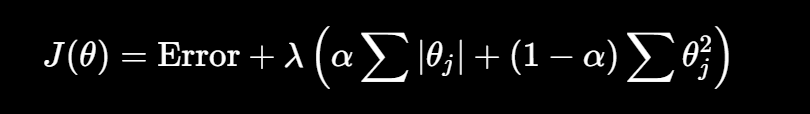



---

## Part 1

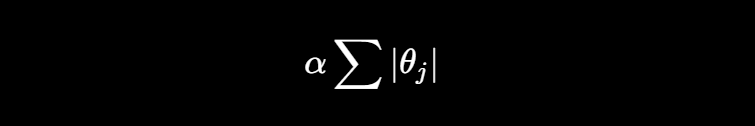

This is the **Lasso (L1)** penalty.

* Removes unimportant features.
* Pushes some coefficients to **0**.

---

## Part 2

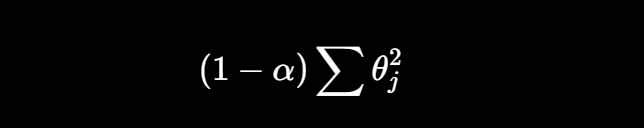

This is the **Ridge (L2)** penalty.

* Shrinks all coefficients.
* Rarely makes them exactly 0.

---

# What is α (alpha)?

**α decides how much Lasso and Ridge contribute.**

Think of it as a **mixing ratio**.

---

### α = 1

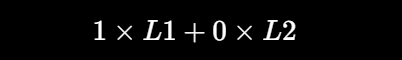

Only Lasso.

---

### α = 0

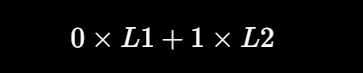

Only Ridge.

---

### α = 0.5


Half Lasso + Half Ridge.

---


# What does λ do now?

Don't confuse **α** and **λ**.

They have different jobs.

### λ

Controls **how much total regularization** is applied.

* Small λ → Weak regularization
* Large λ → Strong regularization

---

### α

Controls **which type of regularization** is used.

* α = 1 → Lasso
* α = 0 → Ridge
* Between 0 and 1 → Mixture

---

# Example

Suppose your features are:

```text
Area
Bedrooms
Garage
House ID
Phone Number
```

Elastic Net may produce:

```text
Area = 210
Bedrooms = 18
Garage = 7500
House ID = 0
Phone Number = 0
```

Notice:

* House ID removed (Lasso behavior)
* Useful coefficients reduced (Ridge behavior)

You get the best of both.

---

# When do we use Elastic Net?

Use it when:

* You have many features.
* Some are irrelevant.
* Some are highly correlated.
* You want feature selection **and** coefficient shrinkage.

---

# Quick Comparison

| Algorithm         | Removes Features? | Shrinks Coefficients?     |
| ----------------- | ----------------- | ------------------------- |
| Linear Regression | ❌                 | ❌                         |
| Ridge             | ❌                 | ✅                         |
| Lasso             | ✅                 | ✅ (some become exactly 0) |
| Elastic Net       | ✅                 | ✅                         |

---


**Ridge Regression (L2):**

> Adds an L2 penalty to shrink coefficients, reducing overfitting without eliminating features.

**Lasso Regression (L1):**

> Adds an L1 penalty that shrinks coefficients and can reduce some of them to exactly zero, performing feature selection.

**Elastic Net:**

> Combines L1 and L2 regularization, providing both feature selection and coefficient shrinkage.

---

## λ and α

* **λ (lambda)** = **"How much regularization?"**
* **α (alpha)** = **"Which regularization? (L1 vs L2)"**
